In [11]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def load_nifti_image(file_path):
    """Load NIfTI image and return the data array."""
    img = nib.load(file_path)
    return img.get_fdata()

def apply_mask(image_data, mask_data, labels_to_zero):
    
    # Create a boolean mask where labels_to_zero are present
    mask_data = np.squeeze(mask_data)
    mask_bool = np.isin(mask_data, labels_to_zero)
    
    # Create a copy to avoid modifying the original data
    masked_image = np.copy(image_data)
    
    # Set values to 0 where mask condition is True
    masked_image[mask_bool] = 0

    return masked_image

def compare_images(image1_path, image2_path, mask_path, output_path=None):
   
    # Load all images
    print("Loading images...")
    img1_data = load_nifti_image(image1_path)
    img2_data = load_nifti_image(image2_path)
    mask_data = load_nifti_image(mask_path)
    
    print(f"Image 1 shape: {img1_data.shape}")
    print(f"Image 2 shape: {img2_data.shape}")
    print(f"Mask shape: {mask_data.shape}")
    # Define labels that should be set to 0
    labels_to_zero = [0, 3, 4, 5 , 7 , 8]
    
    # Apply mask to both images
    print("Applying mask...")
    masked_img1 = apply_mask(img1_data, mask_data, labels_to_zero)
    masked_img2 = apply_mask(img2_data, mask_data, labels_to_zero)
    #masked_img1[masked_img1 > 20] = 0
    #masked_img2[masked_img2 > 20] = 0
    # Select middle slice (axial view)
    slice_idx = img1_data.shape[0] // 2
    print(f"Visualizing slice index: {slice_idx}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
   
    # Method 1: Using numpy flip
    slice1 = masked_img1[:, :, slice_idx]
    slice1_flipped = np.flipud(slice1)  # flip up-down
    
    slice2 = masked_img2[:, :, slice_idx]
    slice2_flipped = np.flipud(slice2)  # flip up-down
    
    
    # Set common color range
    vmin, vmax = 0, 15
    
    im1 = axes[0].imshow(slice1_flipped, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    axes[0].set_title('FEM Electric Field Magnitude (V/m)')
    plt.colorbar(im1, ax=axes[0])
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    im2 = axes[1].imshow(slice2_flipped, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    axes[1].set_title('PINN Electric Field Magnitude (V/m)')
    plt.colorbar(im2, ax=axes[1])
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()
    
    return masked_img1, masked_img2

Loading images...
Image 1 shape: (182, 218, 182)
Image 2 shape: (182, 218, 182)
Mask shape: (182, 218, 182, 1)
Applying mask...
Visualizing slice index: 91


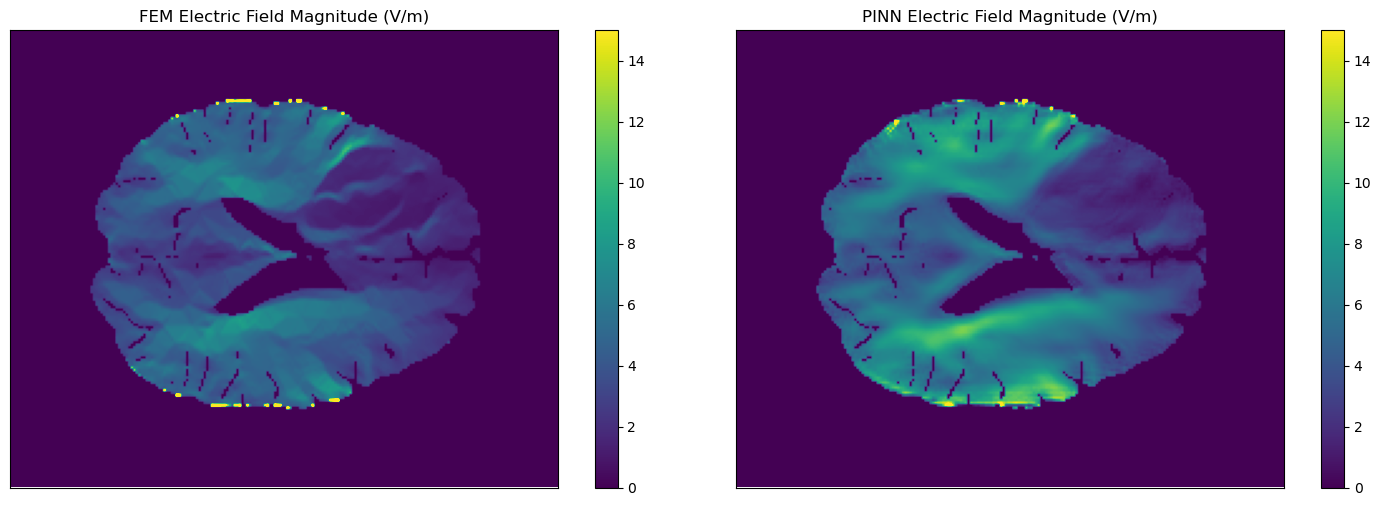

In [12]:
image1_path = "D:/Results/FEM/Electric field energy train 5/FEM/Emagnatude_2.nii.gz"
image2_path = "D:/Results/FEM/Electric field energy train 5/PINN/Emagnatude_2.nii.gz"
mask_path = "D:/Results/FEM/nifti labeled/labeled_FEM-Test_TCGA-02-0027.nii.gz"


# Compare the images
masked_img1, masked_img2  = compare_images(
    image1_path, 
    image2_path, 
    mask_path
)